In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!wget -nc --no-check-certificate https://vision.middlebury.edu/stereo/data/scenes2021/zip/all.zip

--2026-08-18 13:47:19--  https://vision.middlebury.edu/stereo/data/scenes2021/zip/all.zip
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 423330044 (404M) [application/zip]
Saving to: ‘all.zip’

all.zip             100%[===================>] 403.72M  42.2MB/s    in 10s     

2026-08-18 13:47:30 (40.3 MB/s) - ‘all.zip’ saved [423330044/423330044]



In [3]:
!unzip -n -q all.zip -d middlebury_2021_data
print("2021 Dataset downloaded and unzipped successfully!")

2021 Dataset downloaded and unzipped successfully!


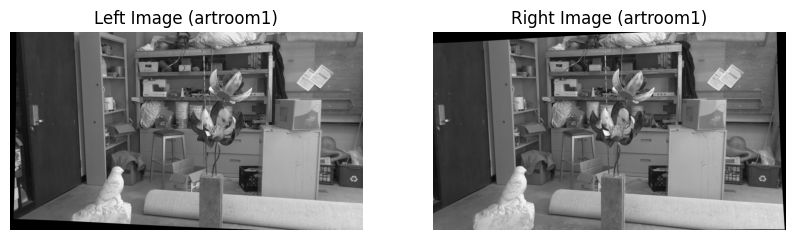

In [4]:
def load_stereo_pair(left_path, right_path):
    """Loads a stereo image pair and converts them to grayscale."""
    imgL = cv2.imread(left_path, cv2.IMREAD_GRAYSCALE)
    imgR = cv2.imread(right_path, cv2.IMREAD_GRAYSCALE)

    if imgL is None or imgR is None:
        raise ValueError(f"Could not load images. Check paths:\nL: {left_path}\nR: {right_path}")

    return imgL, imgR

# Example paths using the 'artroom1' scene from the 2021 dataset
left_img_path = 'middlebury_2021_data/data/artroom1/im0.png'
right_img_path = 'middlebury_2021_data/data/artroom1/im1.png'

imgL, imgR = load_stereo_pair(left_img_path, right_img_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(imgL, cmap='gray')
plt.title('Left Image (artroom1)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgR, cmap='gray')
plt.title('Right Image (artroom1)')
plt.axis('off')
plt.show()


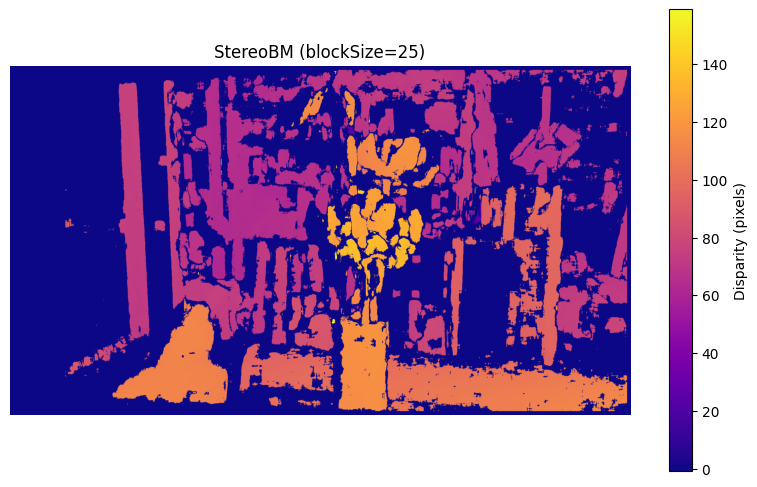

In [5]:
# Initialize StereoBM
# numDisparities: Maximum disparity search range. Must be divisible by 16.
# blockSize: Size of the sliding window (must be odd).
numDisparities = 160  # Adjust based on image resolution
blockSize = 25

stereo_bm = cv2.StereoBM_create(numDisparities=numDisparities, blockSize=blockSize)

# Compute disparity map
# The output is a 16-bit signed integer. We need to divide by 16.0 to get true disparities.
disparity_bm = stereo_bm.compute(imgL, imgR).astype(np.float32) / 16.0

# Visualization
plt.figure(figsize=(10, 6))
plt.imshow(disparity_bm, cmap='plasma')
plt.colorbar(label='Disparity (pixels)')
plt.title(f'StereoBM (blockSize={blockSize})')
plt.axis('off')
plt.show()

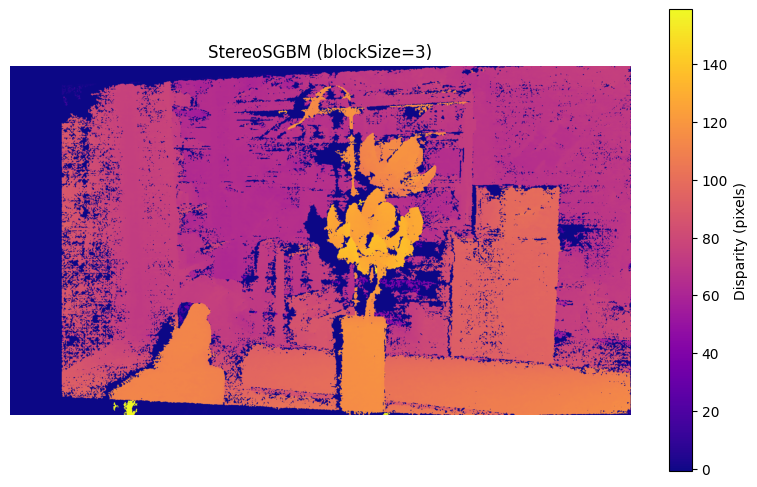

In [6]:
# Parameters for StereoSGBM
minDisparity = 0
numDisparities = 160
blockSize = 3 # SGBM usually works better with smaller block sizes than BM

# P1 and P2 control smoothness.
# P1 is the penalty for a disparity change of 1 pixel.
# P2 is the penalty for a disparity change > 1 pixel.
# OpenCV recommends these formulas:
P1 = 8 * 1 * blockSize**2  # 1 channel (grayscale)
P2 = 32 * 1 * blockSize**2

stereo_sgbm = cv2.StereoSGBM_create(
    minDisparity=minDisparity,
    numDisparities=numDisparities,
    blockSize=blockSize,
    P1=P1,
    P2=P2,
    disp12MaxDiff=1,      # Maximum allowed difference in the left-right check
    uniquenessRatio=10,   # Margin in % by which the best match must "win"
    speckleWindowSize=100,# Maximum size of smooth disparity regions to consider noise
    speckleRange=32,      # Maximum disparity variation within each connected component
    mode=cv2.STEREO_SGBM_MODE_SGBM
)

disparity_sgbm = stereo_sgbm.compute(imgL, imgR).astype(np.float32) / 16.0

plt.figure(figsize=(10, 6))
plt.imshow(disparity_sgbm, cmap='plasma')
plt.colorbar(label='Disparity (pixels)')
plt.title(f'StereoSGBM (blockSize={blockSize})')
plt.axis('off')
plt.show()


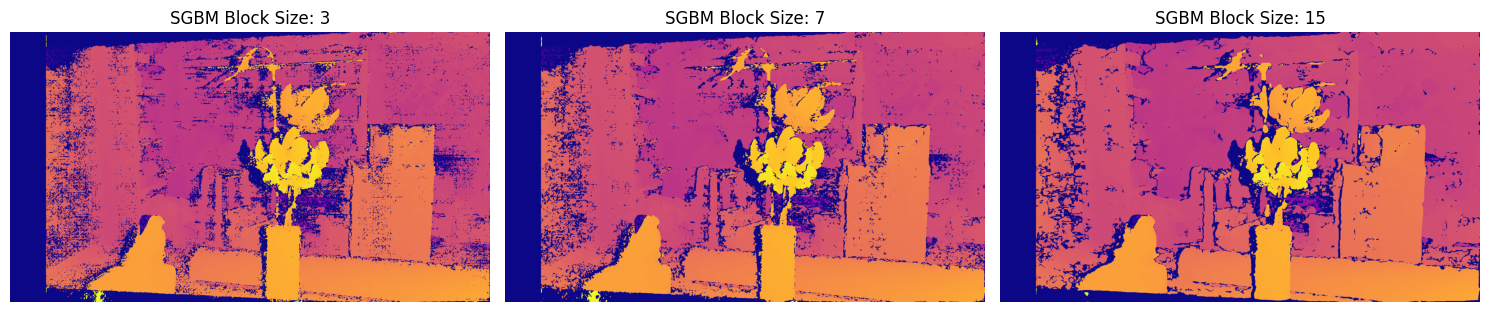

In [7]:
block_sizes = [3, 7, 15]

plt.figure(figsize=(15, 5))
for i, bs in enumerate(block_sizes):
    # Remember to recalculate P1 and P2 when blockSize changes!
    p1 = 8 * 1 * bs**2
    p2 = 32 * 1 * bs**2

    sgbm = cv2.StereoSGBM_create(
        minDisparity=0, numDisparities=144, blockSize=bs,
        P1=p1, P2=p2, uniquenessRatio=10
    )

    disp = sgbm.compute(imgL, imgR).astype(np.float32) / 16.0

    plt.subplot(1, 3, i+1)
    plt.imshow(disp, cmap='plasma')
    plt.title(f'SGBM Block Size: {bs}')
    plt.axis('off')

plt.tight_layout()
plt.show()


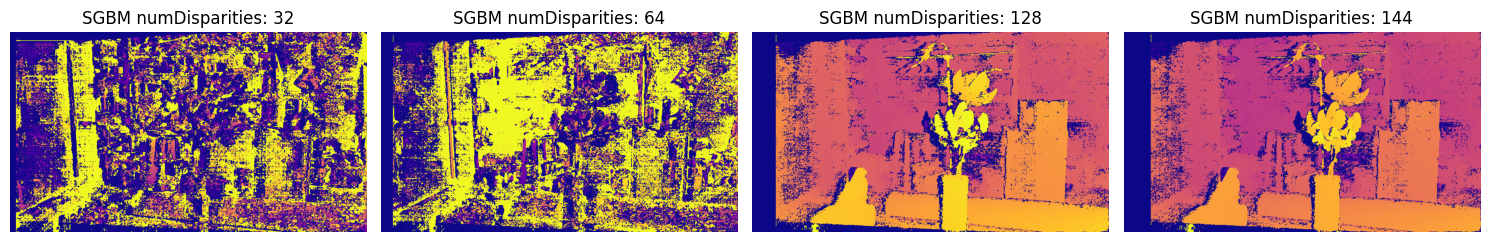

In [8]:
numDisparities = [32, 64, 128, 144]

bs = 5

plt.figure(figsize=(15, 5))
for i, nD in enumerate(numDisparities):
    # Remember to recalculate P1 and P2 when blockSize changes!
    p1 = 8 * 1 * bs**2
    p2 = 32 * 1 * bs**2

    sgbm = cv2.StereoSGBM_create(
        minDisparity=0, numDisparities=nD, blockSize=bs,
        P1=p1, P2=p2, uniquenessRatio=10
    )

    disp = sgbm.compute(imgL, imgR).astype(np.float32) / 16.0

    plt.subplot(1, 4, i+1)
    plt.imshow(disp, cmap='plasma')
    plt.title(f'SGBM numDisparities: {nD}')
    plt.axis('off')

plt.tight_layout()
plt.show()


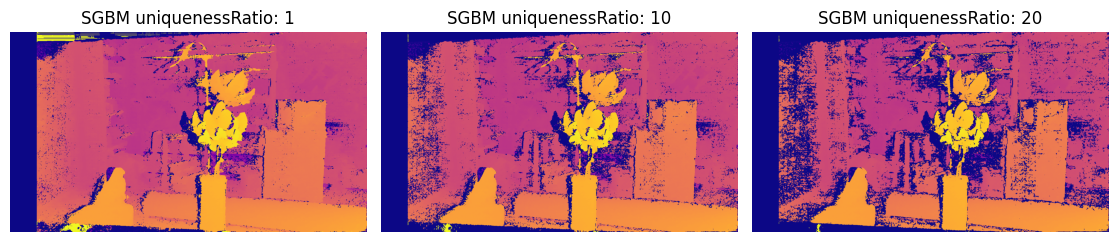

In [9]:
uniquenessRatio = [1, 10, 20]

bs = 5
nD = 144

plt.figure(figsize=(15, 5))
for i, uR in enumerate(uniquenessRatio):
    # Remember to recalculate P1 and P2 when blockSize changes!
    p1 = 8 * 1 * bs**2
    p2 = 32 * 1 * bs**2

    sgbm = cv2.StereoSGBM_create(
        minDisparity=0, numDisparities=nD, blockSize=bs,
        P1=p1, P2=p2, uniquenessRatio=uR
    )

    disp = sgbm.compute(imgL, imgR).astype(np.float32) / 16.0

    plt.subplot(1, 4, i+1)
    plt.imshow(disp, cmap='plasma')
    plt.title(f'SGBM uniquenessRatio: {uR}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Clone the official repository
!git clone https://github.com/princeton-vl/RAFT-Stereo.git
%cd RAFT-Stereo

# Install requirements
!pip install tensorboardX
!pip install einops

# Explicitly create the models directory
!mkdir -p models

# Download a pre-trained model (SceneFlow pre-trained as a starting point)
# Note: In a real scenario, you might download the specific Middlebury weights from their provided Google Drive links.
#!wget -nc https://huggingface.co/spaceuptech/raft-stereo/resolve/main/models/raftstereo-sceneflow.pth -O models/raftstereo-sceneflow.pth


Cloning into 'RAFT-Stereo'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 97 (delta 45), reused 33 (delta 33), pack-reused 29 (from 1)
Receiving objects: 100% (97/97), 706.79 KiB | 2.30 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/RAFT-Stereo
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.0 MB/s eta 0:00:00


In [11]:
!gdown 1e7z5vIo7aFxVl7R5FbflAZlnS2G9IZRj -O models/raftstereo-sceneflow.pth


Downloading...
From (original): https://drive.google.com/uc?id=1e7z5vIo7aFxVl7R5FbflAZlnS2G9IZRj
From (redirected): https://drive.google.com/uc?id=1e7z5vIo7aFxVl7R5FbflAZlnS2G9IZRj&confirm=t&uuid=9a51a47d-77ea-44f1-a28c-f26310ac66ae
To: /content/RAFT-Stereo/models/raftstereo-sceneflow.pth
100% 44.6M/44.6M [00:01<00:00, 39.5MB/s]


In [12]:
!ls

core			     download_models.sh       models
demo.py			     environment_cuda11.yaml  RAFTStereo.png
depth_eq.png		     environment.yaml	      README.md
download_datasets.sh	     evaluate_stereo.py       sampler
download_middlebury_2014.sh  LICENSE		      train_stereo.py


In [37]:
import sys
sys.path.append('core') # Add RAFT core to path

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from raft_stereo import RAFTStereo
from utils.utils import InputPadder

%cd RAFT-Stereo/

# 1. Initialize the Model Configuration (Args)
# We are simulating the argparse object that RAFT usually receives from the terminal.
args = type('', (), {})()
args.restore_ckpt = 'models/raftstereo-sceneflow.pth'
args.shared_backbone = False
args.n_downsample = 2
args.n_gru_layers = 3 # The number of GRU layers in the update block
args.n_gru_vox_iters = 0
args.slow_fast_gru = False
args.valid_iters = 32
args.corr_implementation = 'reg'
args.mixed_precision = False
args.hidden_dims = [128, 128, 128]
args.context_dims = [128, 128, 128]
args.context_norm = "batch"
args.corr_levels = 4
args.corr_radius = 4

model = RAFTStereo(args)
state_dict = torch.load(args.restore_ckpt, map_location='cpu')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # remove 'module.' prefix
    else:
        new_state_dict[k] = v
model.load_state_dict(new_state_dict)
model = model.cuda().eval() # Move to GPU and set to evaluation mode
print("RAFT-Stereo Model Loaded Successfully!")

[Errno 2] No such file or directory: 'RAFT-Stereo/'
/content/RAFT-Stereo
RAFT-Stereo Model Loaded Successfully!


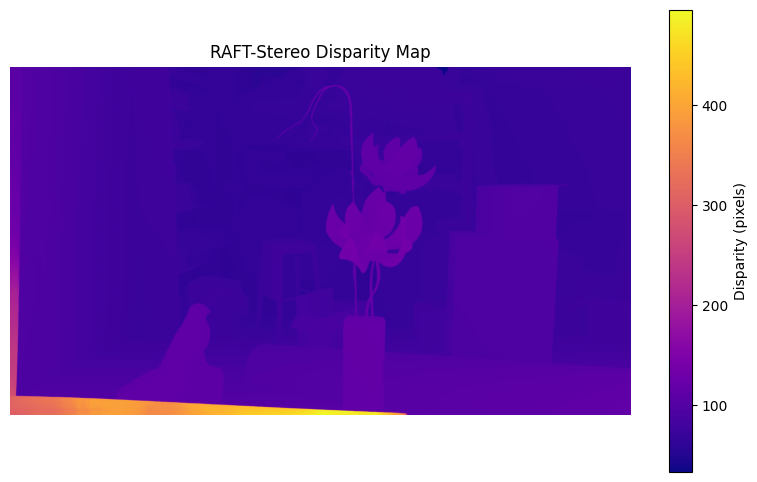

In [23]:
def prepare_image(img_path):
    """Loads an RGB image and converts it to a PyTorch Tensor."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = torch.from_numpy(img).permute(2, 0, 1).float()[None].cuda()
    return img

# Load images (assuming they are in the parent directory from Week 1)
# Adjust paths if your Colab folder structure differs slightly.
img1 = prepare_image('../middlebury_2021_data/data/artroom1/im0.png')
img2 = prepare_image('../middlebury_2021_data/data/artroom1/im1.png')

# RAFT requires image dimensions to be multiples of 8. We use their InputPadder.
padder = InputPadder(img1.shape, divis_by=32)
img1, img2 = padder.pad(img1, img2)

# Run Inference
with torch.no_grad():
    # RAFT outputs a list of disparity maps from its iterative process. We take the last one [-1].
    _, flow_up = model(img1, img2, iters=32, test_mode=True)

# Process the output disparity map
disparity_raft = padder.unpad(flow_up).squeeze().cpu().numpy()
# RAFT returns flow. Horizontal flow is the negative of disparity.
disparity_raft = np.abs(disparity_raft)

# Visualization
plt.figure(figsize=(10, 6))
plt.imshow(disparity_raft, cmap='plasma')
plt.colorbar(label='Disparity (pixels)')
plt.title('RAFT-Stereo Disparity Map')
plt.axis('off')
plt.show()

In [33]:
import sys
import re
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import glob
import os
import numpy as np
import cv2
import torch

# Ensure core is in path
sys.path.append('/content/RAFT-Stereo/core')
from utils.utils import InputPadder

def read_pfm(file_path):
    with open(file_path, 'rb') as file:
        header = file.readline().rstrip().decode("ascii")
        color = (header == 'PF')
        width, height = map(int, file.readline().decode("ascii").split())
        scale = float(file.readline().rstrip().decode("ascii"))
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(file, endian + 'f')
        shape = (height, width, 3) if color else (height, width)
        data = np.reshape(data, shape)
        data = np.flipud(data)
        return data

class MiddleburyDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.scenes = []
        self.crop_size = (384, 512)
        left_images = glob.glob(os.path.join(root_dir, '**', 'im0.png'), recursive=True)
        for imgL_path in left_images:
            scene_dir = os.path.dirname(imgL_path)
            imgR_path = os.path.join(scene_dir, 'im1.png')
            disp_path = os.path.join(scene_dir, 'disp0.pfm')
            if not os.path.exists(disp_path): disp_path = os.path.join(scene_dir, 'disp0GT.pfm')
            if os.path.exists(imgR_path) and os.path.exists(disp_path):
                self.scenes.append({'imgL': imgL_path, 'imgR': imgR_path, 'disp': disp_path})

    def __len__(self): return len(self.scenes)

    def __getitem__(self, idx):
        scene = self.scenes[idx]
        imgL = cv2.cvtColor(cv2.imread(scene['imgL']), cv2.COLOR_BGR2RGB)
        imgR = cv2.cvtColor(cv2.imread(scene['imgR']), cv2.COLOR_BGR2RGB)
        disp_gt = read_pfm(scene['disp'])
        disp_gt[np.isinf(disp_gt)] = 0

        h, w = imgL.shape[:2]
        cy, cx = np.random.randint(0, h - 384 + 1), np.random.randint(0, w - 512 + 1)
        imgL, imgR, disp_gt = imgL[cy:cy+384, cx:cx+512], imgR[cy:cy+384, cx:cx+512], disp_gt[cy:cy+384, cx:cx+512]

        return torch.from_numpy(imgL).permute(2,0,1).float(), torch.from_numpy(imgR).permute(2,0,1).float(), torch.from_numpy(disp_gt.copy()).float()

dataset = MiddleburyDataset('/content/middlebury_2021_data')
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# Ensure model is in training mode and all parameters are trainable
for param in model.fnet.parameters():
    param.requires_grad = False

for param in model.cnet.parameters():
    param.requires_grad = False

# (Optional) If you want to be EXTREMELY strict and freeze the GRU too,
# only leaving the absolute final convolutional flow predictor unfrozen:
#grus_to_freeze = [
#    model.update_block.gru08,
#    model.update_block.gru16,
#    model.update_block.gru32
#]

#for gru in grus_to_freeze:
#    for param in gru.parameters():
#        param.requires_grad = False

for param in model.update_block.parameters():
    param.requires_grad = True

# 1b. Verify what is actually trainable
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
trainable_count = sum(p.numel() for p in trainable_params)
total_count = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_count:,}")
print(f"Trainable Parameters: {trainable_count:,} ({(trainable_count/total_count)*100:.2f}%)")

#optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)
model.train()

epochs = 5
for epoch in range(epochs):
    total_loss = 0.0
    for batch_idx, (imgL, imgR, disp_gt) in enumerate(dataloader):
        imgL, imgR, disp_gt = imgL.cuda(), imgR.cuda(), disp_gt.cuda()
        padder = InputPadder(imgL.shape, divis_by=32)
        imgL_p, imgR_p = padder.pad(imgL, imgR)

        optimizer.zero_grad()
        predictions = model(imgL_p, imgR_p, iters=12)

        # Standardize shapes to (H, W)
        disp_gt = disp_gt.squeeze()
        mask = (disp_gt > 0) & (disp_gt < 300)

        if mask.any():
            loss = 0.0
            for i, pred in enumerate(predictions):
                weight = 0.9 ** (len(predictions) - i - 1)
                # Unpad and squeeze to match (H, W)
                p = padder.unpad(pred).squeeze()
                loss += weight * F.smooth_l1_loss(p[mask], disp_gt[mask], reduction='mean')

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        if batch_idx % 5 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item() if 'loss' in locals() else 0:.4f}")

    print(f"Epoch {epoch+1} Avg Loss: {total_loss/len(dataloader):.4f}")

torch.save(model.state_dict(), '/content/my_finetuned_raft_v2.pth')
print("Training Finished successfully.")

Total Parameters: 11,116,176
Trainable Parameters: 5,728,144 (51.53%)


/content/RAFT-Stereo/core/raft_stereo.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/RAFT-Stereo/core/raft_stereo.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


Epoch 1, Batch 0, Loss: 1730.6113
Epoch 1, Batch 5, Loss: 2599.2493
Epoch 1, Batch 10, Loss: 956.1074
Epoch 1, Batch 15, Loss: 1334.9537
Epoch 1, Batch 20, Loss: 1668.5422
Epoch 1 Avg Loss: 1062.5372
Epoch 2, Batch 0, Loss: 382.9893
Epoch 2, Batch 5, Loss: 285.5878
Epoch 2, Batch 10, Loss: 428.7863
Epoch 2, Batch 15, Loss: 970.7695
Epoch 2, Batch 20, Loss: 385.8355
Epoch 2 Avg Loss: 919.0197
Epoch 3, Batch 0, Loss: 1129.5916
Epoch 3, Batch 5, Loss: 661.4363
Epoch 3, Batch 10, Loss: 465.3054
Epoch 3, Batch 15, Loss: 541.7852
Epoch 3, Batch 20, Loss: 908.0371
Epoch 3 Avg Loss: 618.9038
Epoch 4, Batch 0, Loss: 349.9115
Epoch 4, Batch 5, Loss: 342.6920
Epoch 4, Batch 10, Loss: 347.1221
Epoch 4, Batch 15, Loss: 534.9695
Epoch 4, Batch 20, Loss: 281.6345
Epoch 4 Avg Loss: 455.4724
Epoch 5, Batch 0, Loss: 556.5859
Epoch 5, Batch 5, Loss: 268.2639
Epoch 5, Batch 10, Loss: 303.4244
Epoch 5, Batch 15, Loss: 502.7368
Epoch 5, Batch 20, Loss: 309.4643
Epoch 5 Avg Loss: 394.5327
Training Finished s

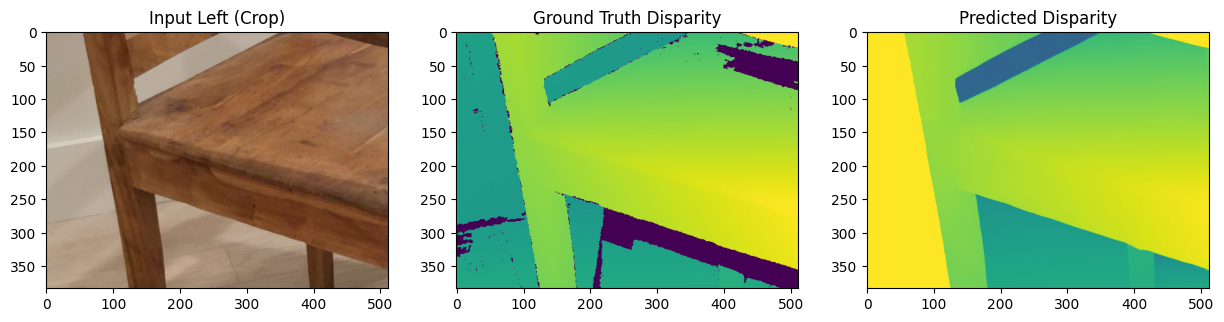

Mean GT value (masked): 114.90
Mean Pred value (masked): 166.84


In [39]:
import matplotlib.pyplot as plt

# Quick sanity check on one batch from the dataloader
model.eval()
with torch.no_grad():
    imgL, imgR, disp_gt = next(iter(dataloader))
    imgL_cuda = imgL.cuda()
    imgR_cuda = imgR.cuda()

    padder = InputPadder(imgL_cuda.shape, divis_by=32)
    imgL_p, imgR_p = padder.pad(imgL_cuda, imgR_cuda)

    _, flow_up = model(imgL_p, imgR_p, iters=32, test_mode=True)
    pred_disp = padder.unpad(flow_up).squeeze().cpu().numpy()
    pred_disp = np.abs(pred_disp)

    gt_disp = disp_gt.squeeze().numpy()
    mask = (gt_disp > 0) & (gt_disp < 250)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(imgL.squeeze().permute(1, 2, 0).numpy().astype(np.uint8))
plt.title('Input Left (Crop)')

plt.subplot(1, 3, 2)
plt.imshow(gt_disp, vmin=0, vmax=150)
plt.title('Ground Truth Disparity')

plt.subplot(1, 3, 3)
plt.imshow(pred_disp, vmin=0, vmax=150)
plt.title('Predicted Disparity')
plt.show()

print(f"Mean GT value (masked): {gt_disp[mask].mean():.2f}")
print(f"Mean Pred value (masked): {pred_disp[mask].mean():.2f}")

In [38]:
import sys
import re
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import glob
import os
import numpy as np
import cv2
import torch

# Ensure core is in path
sys.path.append('/content/RAFT-Stereo/core')
from utils.utils import InputPadder

def read_pfm(file_path):
    with open(file_path, 'rb') as file:
        header = file.readline().rstrip().decode("ascii")
        color = (header == 'PF')
        width, height = map(int, file.readline().decode("ascii").split())
        scale = float(file.readline().rstrip().decode("ascii"))
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(file, endian + 'f')
        shape = (height, width, 3) if color else (height, width)
        data = np.reshape(data, shape)
        data = np.flipud(data)
        return data

class MiddleburyDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.scenes = []
        self.crop_size = (384, 512)
        left_images = glob.glob(os.path.join(root_dir, '**', 'im0.png'), recursive=True)
        for imgL_path in left_images:
            scene_dir = os.path.dirname(imgL_path)
            imgR_path = os.path.join(scene_dir, 'im1.png')
            disp_path = os.path.join(scene_dir, 'disp0.pfm')
            if not os.path.exists(disp_path): disp_path = os.path.join(scene_dir, 'disp0GT.pfm')
            if os.path.exists(imgR_path) and os.path.exists(disp_path):
                self.scenes.append({'imgL': imgL_path, 'imgR': imgR_path, 'disp': disp_path})

    def __len__(self): return len(self.scenes)

    def __getitem__(self, idx):
        scene = self.scenes[idx]
        imgL = cv2.cvtColor(cv2.imread(scene['imgL']), cv2.COLOR_BGR2RGB)
        imgR = cv2.cvtColor(cv2.imread(scene['imgR']), cv2.COLOR_BGR2RGB)
        disp_gt = read_pfm(scene['disp'])
        disp_gt[np.isinf(disp_gt)] = 0

        h, w = imgL.shape[:2]
        cy, cx = np.random.randint(0, h - 384 + 1), np.random.randint(0, w - 512 + 1)
        imgL, imgR, disp_gt = imgL[cy:cy+384, cx:cx+512], imgR[cy:cy+384, cx:cx+512], disp_gt[cy:cy+384, cx:cx+512]

        return torch.from_numpy(imgL).permute(2,0,1).float(), torch.from_numpy(imgR).permute(2,0,1).float(), torch.from_numpy(disp_gt.copy()).float()

dataset = MiddleburyDataset('/content/middlebury_2021_data')
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# Ensure model is in training mode and all parameters are trainable
for param in model.fnet.parameters():
    param.requires_grad = False

for param in model.cnet.parameters():
    param.requires_grad = False

# (Optional) If you want to be EXTREMELY strict and freeze the GRU too,
# only leaving the absolute final convolutional flow predictor unfrozen:
#grus_to_freeze = [
#    model.update_block.gru08,
#    model.update_block.gru16,
#    model.update_block.gru32
#]

#for gru in grus_to_freeze:
#    for param in gru.parameters():
#        param.requires_grad = False

for param in model.update_block.parameters():
    param.requires_grad = False

# UNFREEZE ONLY the flow head (the final output projection)
for param in model.update_block.flow_head.parameters():
    param.requires_grad = True

# 1b. Verify what is actually trainable
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
trainable_count = sum(p.numel() for p in trainable_params)
total_count = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_count:,}")
print(f"Trainable Parameters: {trainable_count:,} ({(trainable_count/total_count)*100:.2f}%)")

#optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)
model.train()

epochs = 5
for epoch in range(epochs):
    total_loss = 0.0
    for batch_idx, (imgL, imgR, disp_gt) in enumerate(dataloader):
        imgL, imgR, disp_gt = imgL.cuda(), imgR.cuda(), disp_gt.cuda()
        padder = InputPadder(imgL.shape, divis_by=32)
        imgL_p, imgR_p = padder.pad(imgL, imgR)

        optimizer.zero_grad()
        predictions = model(imgL_p, imgR_p, iters=12)

        # Standardize shapes to (H, W)
        disp_gt = disp_gt.squeeze()
        mask = (disp_gt > 0) & (disp_gt < 300)

        if mask.any():
            loss = 0.0
            for i, pred in enumerate(predictions):
                weight = 0.9 ** (len(predictions) - i - 1)
                # Unpad and squeeze to match (H, W)
                p = padder.unpad(pred).squeeze()
                loss += weight * F.smooth_l1_loss(p[mask], disp_gt[mask], reduction='mean')

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            total_loss += loss.item()

        if batch_idx % 5 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item() if 'loss' in locals() else 0:.4f}")

    print(f"Epoch {epoch+1} Avg Loss: {total_loss/len(dataloader):.4f}")

torch.save(model.state_dict(), '/content/my_finetuned_raft_v2.pth')
print("Training Finished successfully.")

Total Parameters: 11,116,176
Trainable Parameters: 1,628,034 (14.65%)


/content/RAFT-Stereo/core/raft_stereo.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/RAFT-Stereo/core/raft_stereo.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


Epoch 1, Batch 0, Loss: 2355.7698
Epoch 1, Batch 5, Loss: 633.3474
Epoch 1, Batch 10, Loss: 848.0182
Epoch 1, Batch 15, Loss: 1528.2654
Epoch 1, Batch 20, Loss: 2272.2236
Epoch 1 Avg Loss: 1738.2265
Epoch 2, Batch 0, Loss: 1322.5243
Epoch 2, Batch 5, Loss: 1482.6149
Epoch 2, Batch 10, Loss: 1960.4696
Epoch 2, Batch 15, Loss: 2266.4326
Epoch 2, Batch 20, Loss: 985.8526
Epoch 2 Avg Loss: 1454.2714
Epoch 3, Batch 0, Loss: 1135.8008
Epoch 3, Batch 5, Loss: 1555.7742
Epoch 3, Batch 10, Loss: 2506.6926
Epoch 3, Batch 15, Loss: 2101.5430
Epoch 3, Batch 20, Loss: 1114.1206
Epoch 3 Avg Loss: 1674.9353
Epoch 4, Batch 0, Loss: 1233.0792
Epoch 4, Batch 5, Loss: 724.7863
Epoch 4, Batch 10, Loss: 1156.9664
Epoch 4, Batch 15, Loss: 1097.2058
Epoch 4, Batch 20, Loss: 1201.7363
Epoch 4 Avg Loss: 1455.3616
Epoch 5, Batch 0, Loss: 2195.7290
Epoch 5, Batch 5, Loss: 591.9255
Epoch 5, Batch 10, Loss: 1250.7954
Epoch 5, Batch 15, Loss: 1187.4398
Epoch 5, Batch 20, Loss: 1915.6227
Epoch 5 Avg Loss: 1526.2184


### Comparison of Disparity Maps: SGBM vs. Pre-trained RAFT vs. Fine-tuned RAFT

/content/RAFT-Stereo/core/raft_stereo.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/content/RAFT-Stereo/core/raft_stereo.py:112: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):


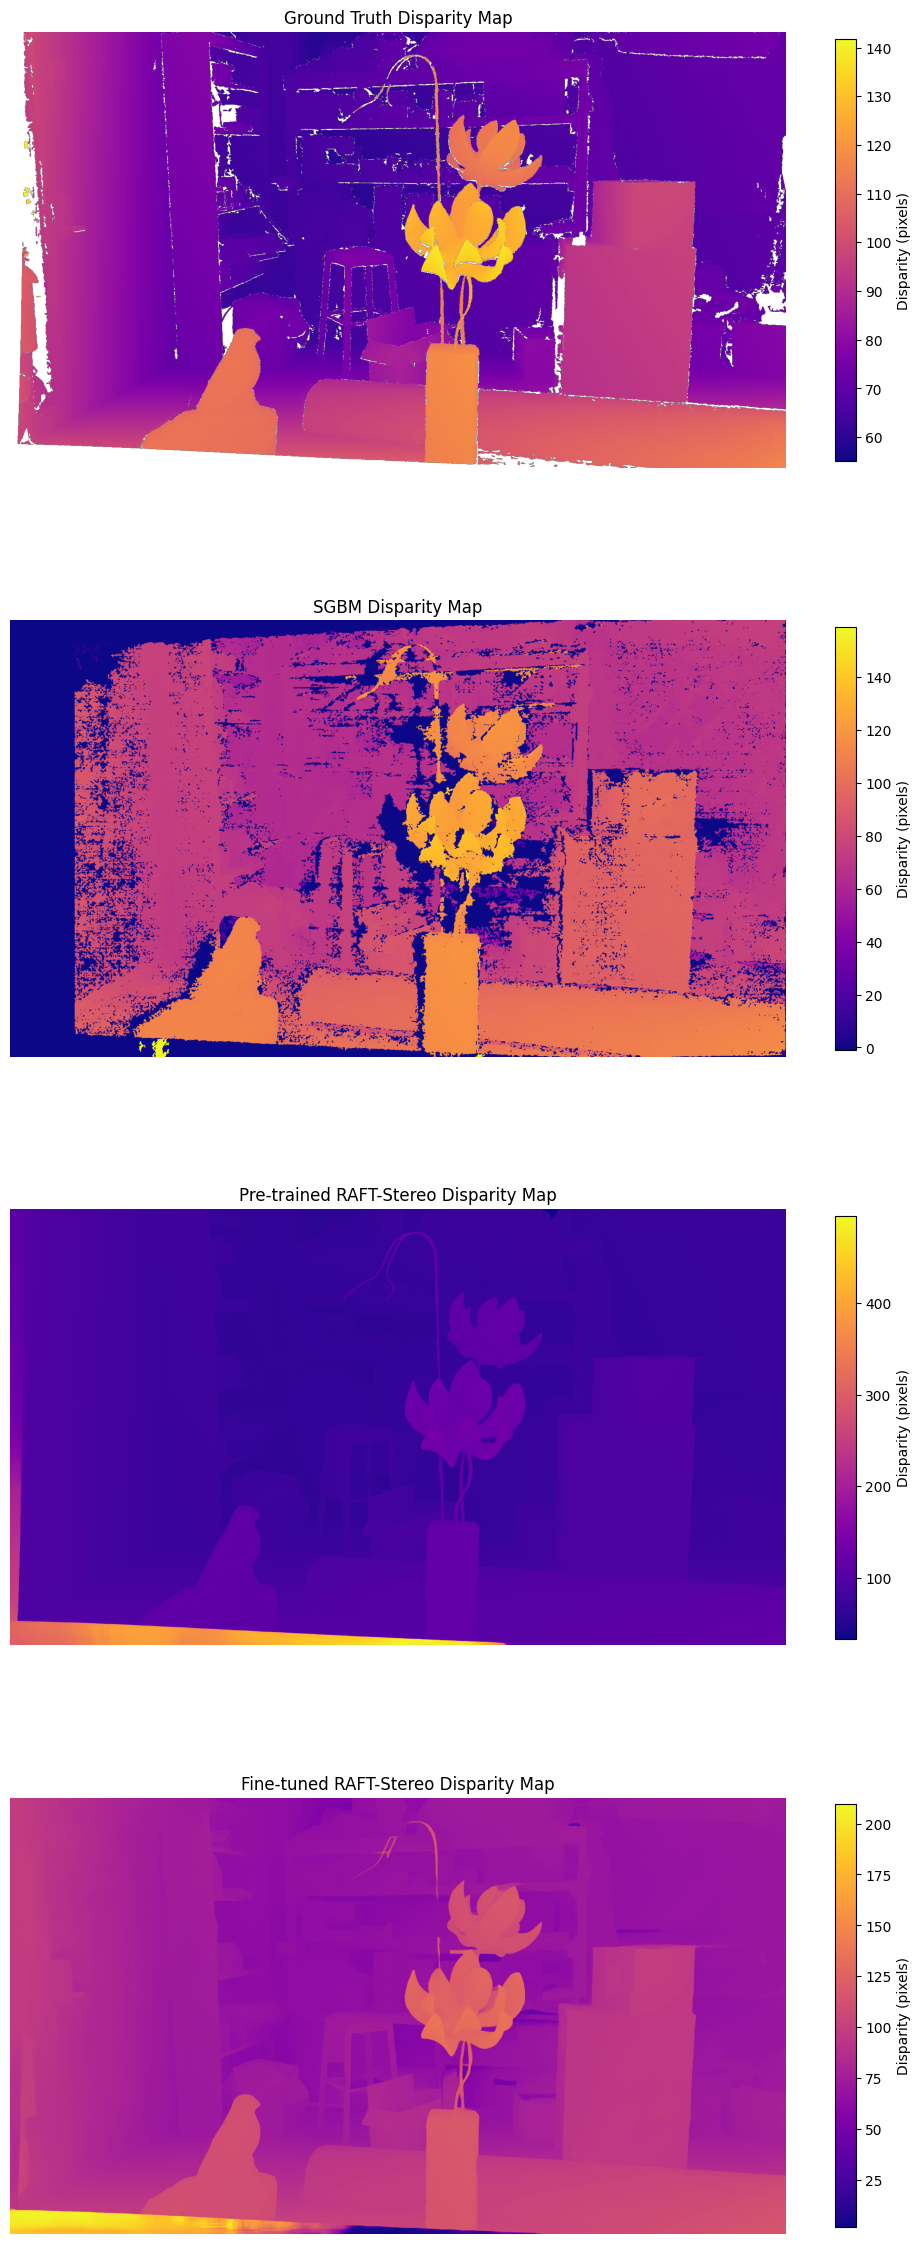

In [41]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from raft_stereo import RAFTStereo
from utils.utils import InputPadder

# Helper function to prepare images (copied from previous cells for clarity)
def prepare_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = torch.from_numpy(img).permute(2, 0, 1).float()[None].cuda()
    return img

# Helper function to read PFM files for ground truth
def read_pfm(file_path):
    with open(file_path, 'rb') as file:
        header = file.readline().rstrip().decode("ascii")
        color = (header == 'PF')
        width, height = map(int, file.readline().decode("ascii").split())
        scale = float(file.readline().rstrip().decode("ascii"))
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(file, endian + 'f')
        shape = (height, width, 3) if color else (height, width)
        data = np.reshape(data, shape)
        data = np.flipud(data)
        return data

# Load the full artroom1 images for consistent comparison
left_img_path_full = '../middlebury_2021_data/data/artroom1/im0.png'
right_img_path_full = '../middlebury_2021_data/data/artroom1/im1.png'
ground_truth_path = '../middlebury_2021_data/data/artroom1/disp0.pfm'

img1_full = prepare_image(left_img_path_full)
img2_full = prepare_image(right_img_path_full)
disp_gt_full = read_pfm(ground_truth_path)

padder_full = InputPadder(img1_full.shape, divis_by=32)
img1_padded, img2_padded = padder_full.pad(img1_full, img2_full)

# --- 1. Get Disparity from SGBM (already computed in disparity_sgbm) ---
# disparity_sgbm is already available from cell awctAKmf-N-J and was computed
# on the full artroom1 images.

# --- 2. Get Disparity from Pre-trained RAFT-Stereo Model ---
# Re-initialize args to match the original model loading parameters
args_pretrained = type('', (), {})()
args_pretrained.restore_ckpt = 'models/raftstereo-sceneflow.pth'
args_pretrained.shared_backbone = False
args_pretrained.n_downsample = 2
args_pretrained.n_gru_layers = 3
args_pretrained.n_gru_vox_iters = 0
args_pretrained.slow_fast_gru = False
args_pretrained.valid_iters = 32
args_pretrained.corr_implementation = 'reg'
args_pretrained.mixed_precision = False
args_pretrained.hidden_dims = [128, 128, 128]
args_pretrained.context_dims = [128, 128, 128]
args_pretrained.context_norm = "batch"
args_pretrained.corr_levels = 4
args_pretrained.corr_radius = 4

model_pretrained = RAFTStereo(args_pretrained)
state_dict_pretrained = torch.load(args_pretrained.restore_ckpt, map_location='cpu')
new_state_dict_pretrained = {}
for k, v in state_dict_pretrained.items():
    if k.startswith('module.'):
        new_state_dict_pretrained[k[7:]] = v
    else:
        new_state_dict_pretrained[k] = v
model_pretrained.load_state_dict(new_state_dict_pretrained)
model_pretrained = model_pretrained.cuda().eval()

with torch.no_grad():
    _, flow_up_pretrained = model_pretrained(img1_padded, img2_padded, iters=32, test_mode=True)
disparity_raft_pretrained = padder_full.unpad(flow_up_pretrained).squeeze().cpu().numpy()
disparity_raft_pretrained = np.abs(disparity_raft_pretrained)

# --- 3. Get Disparity from Fine-tuned RAFT-Stereo Model ---
# Re-initialize args (same as pre-trained, but we'll load different weights)
args_finetuned = type('', (), {})()
args_finetuned.restore_ckpt = 'models/raftstereo-sceneflow.pth' # Placeholder, weights will be overridden
args_finetuned.shared_backbone = False
args_finetuned.n_downsample = 2
args_finetuned.n_gru_layers = 3
args_finetuned.n_gru_vox_iters = 0
args_finetuned.slow_fast_gru = False
args_finetuned.valid_iters = 32
args_finetuned.corr_implementation = 'reg'
args_finetuned.mixed_precision = False
args_finetuned.hidden_dims = [128, 128, 128]
args_finetuned.context_dims = [128, 128, 128]
args_finetuned.context_norm = "batch"
args_finetuned.corr_levels = 4
args_finetuned.corr_radius = 4

model_finetuned = RAFTStereo(args_finetuned)
model_finetuned.load_state_dict(torch.load('/content/my_finetuned_raft_v2.pth', map_location='cpu'))
model_finetuned = model_finetuned.cuda().eval()

with torch.no_grad():
    _, flow_up_finetuned = model_finetuned(img1_padded, img2_padded, iters=32, test_mode=True)
disparity_raft_finetuned = padder_full.unpad(flow_up_finetuned).squeeze().cpu().numpy()
disparity_raft_finetuned = np.abs(disparity_raft_finetuned)

# --- Visualization ---
plt.figure(figsize=(10, 24)) # Increased figure height for 4 vertical plots

plt.subplot(4, 1, 1)
plt.imshow(disp_gt_full, cmap='plasma')
plt.colorbar(label='Disparity (pixels)', shrink=0.7)
plt.title('Ground Truth Disparity Map')
plt.axis('off')

plt.subplot(4, 1, 2)
plt.imshow(disparity_sgbm, cmap='plasma')
plt.colorbar(label='Disparity (pixels)', shrink=0.7)
plt.title('SGBM Disparity Map')
plt.axis('off')

plt.subplot(4, 1, 3)
plt.imshow(disparity_raft_pretrained, cmap='plasma')
plt.colorbar(label='Disparity (pixels)', shrink=0.7)
plt.title('Pre-trained RAFT-Stereo Disparity Map')
plt.axis('off')

plt.subplot(4, 1, 4)
plt.imshow(disparity_raft_finetuned, cmap='plasma')
plt.colorbar(label='Disparity (pixels)', shrink=0.7)
plt.title('Fine-tuned RAFT-Stereo Disparity Map')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def prepare_image(img_path):
    """Loads an RGB image and converts it to a PyTorch Tensor."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = torch.from_numpy(img).permute(2, 0, 1).float()[None].cuda()
    return img

# Load images (assuming they are in the parent directory from Week 1)
# Adjust paths if your Colab folder structure differs slightly.
img1 = prepare_image('middlebury_2021_data/data/artroom1/im0.png')
img2 = prepare_image('middlebury_2021_data/data/artroom1/im1.png')

# RAFT requires image dimensions to be multiples of 8. We use their InputPadder.
padder = InputPadder(img1.shape, divis_by=32)
img1, img2 = padder.pad(img1, img2)

# Run Inference
with torch.no_grad():
    # RAFT outputs a list of disparity maps from its iterative process. We take the last one [-1].
    _, flow_up = model(img1, img2, iters=32, test_mode=True)

# Process the output disparity map
disparity_raft = padder.unpad(flow_up).squeeze().cpu().numpy()
# RAFT returns flow. Horizontal flow is the negative of disparity.
disparity_raft = np.abs(disparity_raft)

# Visualization
plt.figure(figsize=(10, 6))
plt.imshow(disparity_raft, cmap='plasma')
plt.colorbar(label='Disparity (pixels)')
plt.title('RAFT-Stereo Disparity Map')
plt.axis('off')
plt.show()

In [ ]:
print(f"GT Max Value: {disp_gt.max()}")
print(f"Prediction Max Value: {final_pred.max()}")